In [1]:
!pip install rasterio -q

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
PROJECT_DIR = "/content/drive/MyDrive/Landslide-Hazard-Zonation"

OUTPUT_RASTERS = os.path.join(PROJECT_DIR, "outputs", "rasters")
OUTPUT_FIGURES = os.path.join(PROJECT_DIR, "outputs", "figures")

LULC_PATH = os.path.join(OUTPUT_RASTERS, "LULC_2021.tif")

print(LULC_PATH)
print(os.path.exists(LULC_PATH))

/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/LULC_2021.tif
True


In [5]:
with rasterio.open(LULC_PATH) as src:
    lulc = src.read(1)
    profile = src.profile

print(profile)
print("Shape:", lulc.shape)

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 8629, 'height': 11986, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 43N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32643"]]'), 'transform': Affine(10.0, 0.0, 678670.0,
       0.0, -10.0, 1145660.0), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}
Shape: (11986, 8629)


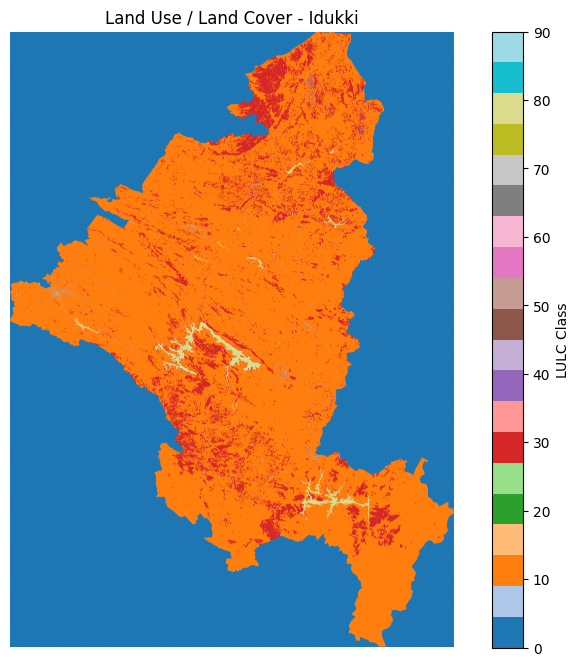

In [6]:
plt.figure(figsize=(10, 8))

plt.imshow(lulc, cmap="tab20")
plt.colorbar(label="LULC Class")

plt.title("Land Use / Land Cover - Idukki")
plt.axis("off")

plt.show()

In [7]:
unique, counts = np.unique(lulc, return_counts=True)

print("LULC Classes and Pixel Counts:\n")

for value, count in zip(unique, counts):
    print(f"Class {value}: {count:,} pixels")

LULC Classes and Pixel Counts:

Class 0: 59,816,401 pixels
Class 10: 36,672,224 pixels
Class 20: 318 pixels
Class 30: 5,918,798 pixels
Class 40: 49,860 pixels
Class 50: 285,422 pixels
Class 60: 9,724 pixels
Class 80: 674,407 pixels
Class 90: 40 pixels


In [8]:
lulc_classes = {
    10: "Tree Cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / Sparse Vegetation",
    70: "Snow & Ice",
    80: "Permanent Water",
    90: "Herbaceous Wetland",
    95: "Mangroves",
    100: "Moss & Lichen"
}

print("Classes present in the study area:\n")

for value in unique:
    if value in lulc_classes:
        print(f"{value}: {lulc_classes[value]}")

Classes present in the study area:

10: Tree Cover
20: Shrubland
30: Grassland
40: Cropland
50: Built-up
60: Bare / Sparse Vegetation
80: Permanent Water
90: Herbaceous Wetland


In [9]:
figure_path = os.path.join(
    OUTPUT_FIGURES,
    "lulc_map.png"
)

plt.figure(figsize=(10, 8))
plt.imshow(lulc, cmap="tab20")
plt.title("Land Use / Land Cover - Idukki")
plt.axis("off")

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.close()

print("Saved:", figure_path)

Saved: /content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/figures/lulc_map.png
